In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# EXPORT: src/lib/functions.py


class Logloss:
    def __init__(self):
        pass

    def forward(self, y_true, y_pred, eps=1e-15):
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.log(np.sum(y_true * y_pred))

    def gradient(self, y_true, y_pred, eps=1e-15):
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -y_true / np.sum(y_true * y_pred)



class Sigmoid:
    def __init__(self):
        pass

    def forward(self, x):
        return 1 / (1 + np.exp(-x))

    def gradient(self, x):
        sig = self.forward(x)
        return sig * (1 - sig)


class ReLU:
    def __init__(self):
        pass

    def forward(self, x):
        return np.maximum(0, x)

    def gradient(self, x):
        return (x > 0).astype(int)


class Softmax:
    def __init__(self):
        pass

    def forward(self, x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)

    def gradient(self, x):
        s = self.forward(x).reshape(-1, 1)
        return np.diagflat(s) - np.dot(s, s.T)

In [ ]:
# EXPORT: src/lib/neural_network.py


class NeuralNetwork:
    def __init__(
        self,
        layers_dimensions,
        input_dim,
        hidden_activation=ReLU(),
        loss=Logloss(),
        output_activation=None,
    ):
        self.training_cache = None
        self.error_cache = None
        self.n_layers = len(layers_dimensions)
        self.layers_dimensions = layers_dimensions

        # First layer, hidden layers then output layer
        self.nn = [self.build_layer(layers_dimensions[0], input_dim)]
        self.nn.extend(
            [
                self.build_layer(
                    layers_dimensions[layer_dim], layers_dimensions[layer_dim - 1]
                )
                for layer_dim in range(1, self.n_layers)
            ]
        )
        self.bias = [np.zeros(layer_dim) for layer_dim in layers_dimensions]

        self.hidden_activation = hidden_activation
        self.output_activation = (
            output_activation if output_activation else hidden_activation
        )  # typically sigmoid or softmax but not mandatory
        self.loss = loss

    def get_values(
        self,
        n_epoch=None,
        n_batch=None,
        n_sample=None,
        n_layer=-1,
        after_activation=True,
        include_error=False,
        chart=True,
        display=False,
        aggregate_error="mean",
        return_dict=False,
    ):
        """
        Unified accessor for training cache and error cache.

        Parameters
        ----------
        n_epoch, n_batch, n_sample, n_layer:
            Select indices. Accepts:
            - None  -> all
            - int   -> one index
            - list/tuple of ints -> multiple indices
            Negative indices are supported.

        after_activation : bool
            Only used when reading training_cache.
            True  -> post-activation values
            False -> pre-activation values

        include_error : bool
            If True, also returns values from self.error_cache.

        display : bool
            If True, prints a readable summary and plots error evolution if available.

        aggregate_error : {"mean", "sum"}
            How to aggregate sample errors inside each batch for the chart.

        return_dict : bool
            If True, always returns a dict with keys like {"values": ..., "errors": ...}
            If False:
                - returns values only if include_error=False
                - returns {"values": ..., "errors": ...} if include_error=True
        """

        if self.training_cache is None and not include_error:
            return (
                "No predictions, try NeuralNetwork.train() before calling this method."
            )

        if include_error and getattr(self, "error_cache", None) is None:
            return (
                "No error cache, try NeuralNetwork.train() before calling this method."
            )

        act_idx = 1 if after_activation else 0

        def _indices(sel, length):
            if sel is None:
                return list(range(length))

            if isinstance(sel, (int, np.integer)):
                sel = [int(sel)]
            else:
                sel = [int(x) for x in sel]

            out = []
            for i in sel:
                if i < 0:
                    i = length + i
                if 0 <= i < length:
                    out.append(i)
                else:
                    raise IndexError(f"Index {i} out of range for length {length}")
            return out

        result = {}

        # --------------------------------------------------
        # 1) Collect training cache values
        # --------------------------------------------------
        if self.training_cache is not None:
            values = []

            E = len(self.training_cache)
            for e in _indices(n_epoch, E):
                B = len(self.training_cache[e])
                for b in _indices(n_batch, B):
                    S = len(self.training_cache[e][b])
                    for s in _indices(n_sample, S):
                        L = len(self.training_cache[e][b][s])
                        for l in _indices(n_layer, L):
                            values.append(self.training_cache[e][b][s][l][act_idx])

            try:
                result["values"] = np.stack(values, axis=0)
            except Exception:
                result["values"] = np.array(values, dtype=object)

        # --------------------------------------------------
        # 2) Collect error cache values
        # --------------------------------------------------
        if include_error:
            errors = []

            E = len(self.error_cache)
            for e in _indices(n_epoch, E):
                B = len(self.error_cache[e])
                for b in _indices(n_batch, B):
                    S = len(self.error_cache[e][b])
                    for s in _indices(n_sample, S):
                        errors.append(self.error_cache[e][b][s])

            try:
                result["errors"] = np.stack(errors, axis=0)
            except Exception:
                result["errors"] = np.array(errors, dtype=object)

        # --------------------------------------------------
        # 3) Optional display
        # --------------------------------------------------
        if display:
            print("=" * 50)
            print("Neural Network Cache Summary")
            print("=" * 50)

            if "values" in result:
                vals = result["values"]
                print("Predictions / activations:")
                print(f"  type   : {type(vals)}")
                print(f"  shape  : {getattr(vals, 'shape', 'ragged')}")
                print(
                    f"  mode   : {'post-activation' if after_activation else 'pre-activation'}"
                )
                print(f"  layer  : {n_layer}")
                print()

            if "errors" in result:
                errs = result["errors"]
                print("Errors:")
                print(f"  type   : {type(errs)}")
                print(f"  shape  : {getattr(errs, 'shape', 'ragged')}")

                # global stats if numeric
                try:
                    errs_num = np.array(errs, dtype=float)
                    print(f"  mean   : {np.mean(errs_num):.6f}")
                    print(f"  std    : {np.std(errs_num):.6f}")
                    print(f"  min    : {np.min(errs_num):.6f}")
                    print(f"  max    : {np.max(errs_num):.6f}")
                except Exception:
                    print("  stats  : unavailable (non-numeric/ragged errors)")
                print()

        if chart:
            # ----------------------------------------------
            # Plot batch-wise error evolution over training
            # ----------------------------------------------
            if include_error and getattr(self, "error_cache", None) is not None:
                try:
                    error_curve = []
                    x_labels = []

                    E_idx = _indices(n_epoch, len(self.error_cache))

                    for e in E_idx:
                        B_idx = _indices(n_batch, len(self.error_cache[e]))
                        for b in B_idx:
                            batch_errors = []

                            S_idx = _indices(n_sample, len(self.error_cache[e][b]))
                            for s in S_idx:
                                val = self.error_cache[e][b][s]

                                # scalar error
                                if np.isscalar(val):
                                    batch_errors.append(float(val))
                                else:
                                    arr = np.array(val, dtype=float)
                                    # reduce vector errors to one sample score
                                    batch_errors.append(np.mean(np.abs(arr)))

                            if len(batch_errors) > 0:
                                if aggregate_error == "sum":
                                    agg = np.sum(batch_errors)
                                else:
                                    agg = np.mean(batch_errors)

                                error_curve.append(agg)
                                x_labels.append(f"E{e}B{b}")

                    if len(error_curve) > 0:
                        plt.figure(figsize=(10, 4))
                        plt.plot(error_curve, marker="o")
                        plt.title(f"Error evolution ({aggregate_error} per batch)")
                        plt.xlabel("Batch step")
                        plt.ylabel("Error")
                        plt.grid(True, alpha=0.3)

                        # only show labels if not too many
                        if len(x_labels) <= 25:
                            plt.xticks(range(len(x_labels)), x_labels, rotation=45)

                        plt.tight_layout()
                        plt.show()

                except Exception as exc:
                    print(f"Could not plot error curve: {exc}")

        # --------------------------------------------------
        # 4) Return
        # --------------------------------------------------
        if return_dict or include_error:
            return result

        return result.get("values", None)

    def plot_confusion_matrix(self, y_true, y_pred):
        """
        Compute, print, and plot a confusion matrix without sklearn.

        Parameters
        ----------
        y_true : array-like
            True labels (1D vector)
        y_pred : array-like
            Predicted labels (1D vector)
        """

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Find unique classes
        classes = np.unique(np.concatenate((y_true, y_pred)))
        n_classes = len(classes)

        # Map labels to indices
        class_to_index = {c: i for i, c in enumerate(classes)}

        # Build confusion matrix
        cm = np.zeros((n_classes, n_classes), dtype=int)

        for t, p in zip(y_true, y_pred):
            i = class_to_index[t]
            j = class_to_index[p]
            cm[i, j] += 1

        # Plot
        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion Matrix")
        plt.colorbar()

        ticks = np.arange(n_classes)
        plt.xticks(ticks, classes)
        plt.yticks(ticks, classes)

        plt.xlabel("Predicted label")
        plt.ylabel("True label")

        # Write values in cells
        for i in range(n_classes):
            for j in range(n_classes):
                plt.text(j, i, cm[i, j], ha="center", va="center")

        plt.tight_layout()
        plt.show()

        return cm

    def build_layer(self, layer_dim, neuron_dim, limit=1):
        return np.array(
            [np.random.uniform(-limit, limit, neuron_dim) for _ in range(layer_dim)]
        )

    def forward(self, x, layer_n):  # forward from layer_n to layer_n + 1
        linear_transform = self.nn[layer_n].dot(x) + self.bias[layer_n]

        if layer_n == self.n_layers - 1:
            return linear_transform, self.output_activation.forward(linear_transform)

        return linear_transform, self.hidden_activation.forward(linear_transform)

    def backprop(self, batch_cache, X_batch, Y_batch, learning_rate):
        # dW : parameters error
        # dB : bias error
        dW, dB = (
            [np.zeros_like(W) for W in self.nn],
            [np.zeros_like(b) for b in self.bias],
        )

        for n, sample in enumerate(batch_cache):
            y_true = Y_batch[n]

            # last_z : last layer values (e.g. prediction) before activation
            # last_a : last layer values (e.g. prediction) after activation
            last_z, last_a = sample[-1]
            pred = last_a

            # dLoss/dlast_a (Loss gradient wrt prediction)
            da = self.loss.gradient(y_true, pred)

            # d_activation/d_last_z (Activation gradient wrt prediction)
            dz = da.dot(self.output_activation.gradient(last_z))

            # backprop
            for layer in range(self.n_layers - 1, -1, -1):
                # layer_input is the input of the current layer (e.g. the output of the previous one)
                # as X_batch does not contain the initial sample, we have to use an if statement
                if layer == 0:
                    layer_input = X_batch[n]
                else:
                    layer_input = sample[layer - 1][1]

                # np.outer(dz, layer_input) is
                dW[layer] += np.outer(dz, layer_input)
                dB[layer] += dz

                # propagate to previous layer
                if layer > 0:
                    da_prev = self.nn[layer].T @ dz
                    z_prev = sample[layer - 1][0]
                    dz = da_prev * self.hidden_activation.gradient(z_prev)

            # applying correction
            for layer in range(self.n_layers):
                self.nn[layer] -= learning_rate * dW[layer]
                self.bias[layer] -= learning_rate * dB[layer]

    def train(self, X_train, Y_train, batch_size, epochs, learning_rate=0.01):
        if batch_size > X_train.shape[0]:
            raise Exception("batch_size > n_samples, exiting...")

        # caching all values, 2 for each neuron (pre-activation and post-activation)
        global_training_cache = []
        global_error_cache = []

        for e in range(epochs):
            current_line = 0
            epoch_training_cache = []
            epoch_error_cache = []

            while current_line < X_train.shape[0]:
                batch_X = X_train[current_line : current_line + batch_size]
                batch_Y = Y_train[current_line : current_line + batch_size]
                batch_training_cache = []
                batch_error_cache = []

                for sample in range(batch_X.shape[0]):
                    sample_training_cache = [None] * self.n_layers
                    x = batch_X[sample]

                    for layer in range(self.n_layers):
                        sample_training_cache[layer] = self.forward(x, layer)
                        x = sample_training_cache[layer][1]

                    batch_training_cache.append(sample_training_cache)
                    batch_error_cache.append(self.loss.forward(batch_Y[sample], x))

                self.backprop(batch_training_cache, batch_X, batch_Y, learning_rate)

                epoch_training_cache.append(batch_training_cache)
                epoch_error_cache.append(batch_error_cache)

                current_line += batch_size

            global_training_cache.append(epoch_training_cache)
            global_error_cache.append(epoch_error_cache)

        self.training_cache = global_training_cache
        self.error_cache = global_error_cache

In [ ]:
# EXPORT: src/main.py

from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target
y_ohe = np.array(
    [
        [1 if i == value else 0 for i in range(10)]
        for _, value in enumerate(digits.target)
    ]
)  # one hot encoding for targets

nn = NeuralNetwork(
    layers_dimensions=[15, 10],
    input_dim=X.shape[1],
    hidden_activation=Sigmoid(),
    loss=Logloss(),
    output_activation=Softmax(),
)
nn.train(X, y_ohe, batch_size=10, epochs=15, learning_rate=0.001)

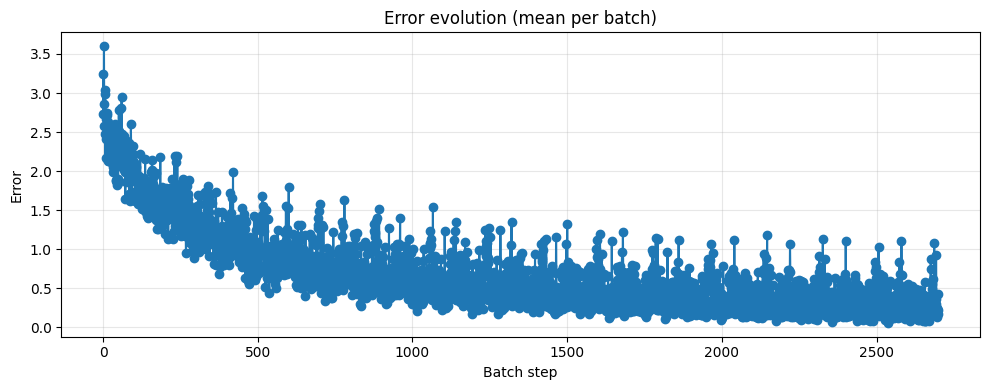

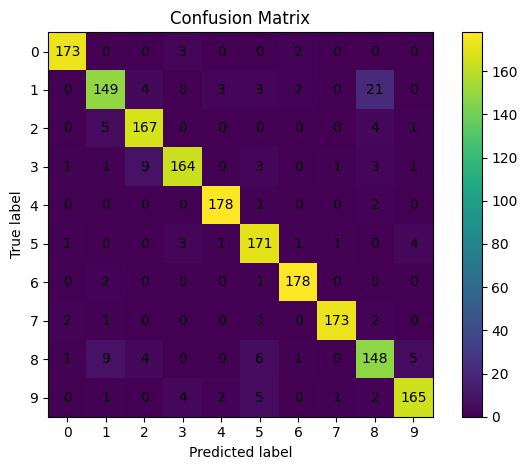

array([[173,   0,   0,   3,   0,   0,   2,   0,   0,   0],
       [  0, 149,   4,   0,   3,   3,   2,   0,  21,   0],
       [  0,   5, 167,   0,   0,   0,   0,   0,   4,   1],
       [  1,   1,   9, 164,   0,   3,   0,   1,   3,   1],
       [  0,   0,   0,   0, 178,   1,   0,   0,   2,   0],
       [  1,   0,   0,   3,   1, 171,   1,   1,   0,   4],
       [  0,   2,   0,   0,   0,   1, 178,   0,   0,   0],
       [  2,   1,   0,   0,   0,   1,   0, 173,   2,   0],
       [  1,   9,   4,   0,   0,   6,   1,   0, 148,   5],
       [  0,   1,   0,   4,   2,   5,   0,   1,   2, 165]])

In [ ]:
_ = nn.get_values(display=False, chart=True, return_dict=False, include_error=True)
_ = nn.plot_confusion_matrix(y, np.argmax(nn.get_values(n_epoch=-1), axis=1))